# Solver settings: time against accuracy

The mesh decides how close the discretised cavity is to the real one; the previous two
examples measure that. The eigensolver's settings decide how close the answer is to the
discretised cavity, and how long it takes to get there. This example measures what each
setting costs and buys, so you can trade accuracy for speed knowingly.

`cav.eigenmode.benchmark` does the measuring. Every point is a complete simulation (mesh,
solve and every figure of merit), repeated five times, and scored against a solve of the
same mesh converged far beyond any setting being compared. The errors here are therefore
the solver's alone. Times are the mean and standard deviation over the repeats. Errors
vary over orders of magnitude from run to run, so each is the mean of its logarithm, drawn
with a spread of $10^{\mu\pm\sigma}$.

The settings compared:

| setting | what it does |
|---|---|
| `pinvit_tol` | the eigensolver stops once every checked mode's relative residual is below it (default `1e-8`) |
| `pinvit_converge_modes` | how many of the lowest modes must converge (default: all `n_modes`) |
| `pinvit_padding` | extra vectors the eigensolver iterates on beyond `n_modes` (default: twice `n_modes`, at most 30) |
| `preconditioner` | `'direct'` (default), an exact factorisation, or `'bddc'`, an approximate one |
| `direct_solver` | the sparse direct solver for every factorisation (default `'sparsecholesky'`) |

The timings are from the machine that built these pages. Run the notebook on yours to get
your own; it is also the way to check a new setting, which is one more entry in
`variants`.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.printing import set_verbose
from cavsim2d.utils.style import apply_style

set_verbose(False)
apply_style()
WORK = tempfile.mkdtemp()

MID = [42, 42, 12, 19, 35, 57.652, 103.3536]      # TESLA mid-cell: A, B, a, b, Ri, L, Req [mm]
CONFIG = {'boundary_conditions': 'mm', 'mesh_config': {'h': 20, 'p': 3}}   # the defaults
TOLERANCES = [1e-4, 1e-6, 1e-8, 1e-10]


def tesla(n_cells):
    cav = EllipticalCavity(n_cells, MID, MID, MID, beampipe='both', name=f'tesla_{n_cells}cell')
    cav.set_workspace(os.path.join(WORK, cav.name))
    return cav


def show(table):
    '''Round a benchmark table for reading.'''
    fmt = {c: '{:.1e}' for c in table.columns}
    fmt.update({'time per simulation [s]': '{:.2f}', 'std [s]': '{:.2f}',
                'solve [s]': '{:.2f}', 'PINVIT iterations': '{:.0f}'})
    return table.style.format(fmt).format_index(
        lambda v: f'{v:.0e}' if isinstance(v, float) else v)

## 1. Tolerance and preconditioner on a single cell

A TESLA mid-cell with beam pipes, on the default mesh. The direct and BDDC preconditioners
are each run at four tolerances.

In [2]:
cell = tesla(1)
cell.eigenmode.benchmark(variants={'direct': {}, 'bddc': {'preconditioner': 'bddc'}},
                         sweep={'pinvit_tol': TOLERANCES}, n_repeats=5,
                         eigenmode_config=CONFIG)
show(cell.eigenmode.benchmark_table())

Each column is a worst relative error over the modes reported: the frequency of the mode of
interest (the accelerating mode), of the passband (the lowest `n_cells` modes) and of every
reported mode, then R/Q, Epk/Eacc and Bpk/Eacc over the modes that carry a voltage, and G over
every mode.

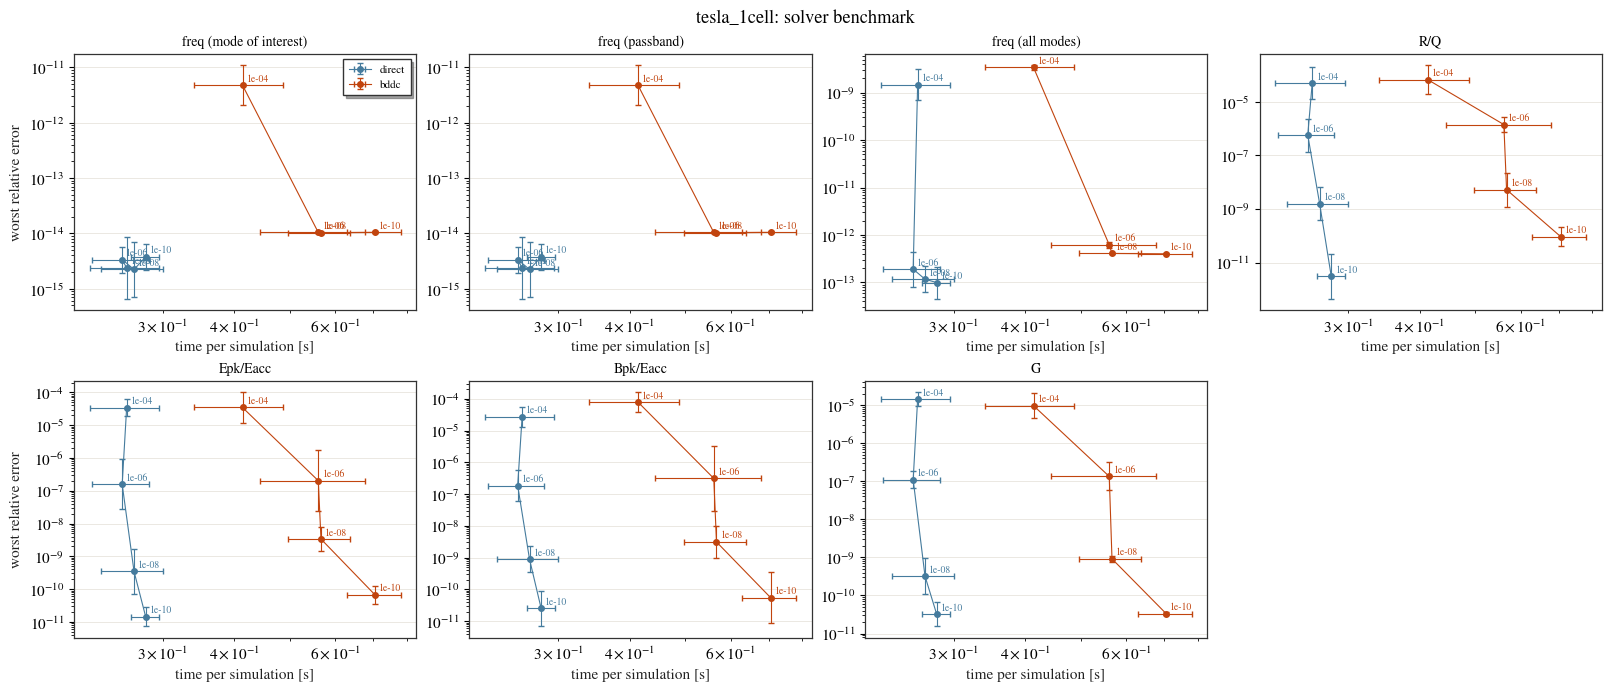

In [3]:
cell.eigenmode.plot_benchmark()
plt.show()

On a single cell the direct preconditioner is the faster of the two at every tolerance:
0.25 to 0.28 s per simulation against 0.41 to 0.70 s for BDDC. BDDC needs six times as
many iterations (40 to 108 against 7 to 17), and each one is not correspondingly cheaper.
Direct iterations are so cheap here that tightening the tolerance from $10^{-4}$ to
$10^{-10}$ costs almost nothing: meshing and the figures of merit take most of the time.

The tolerance buys accuracy in the fields, close to one decade for one decade. At the
default `1e-8` every figure of merit is within $2\times10^{-9}$ of the reference; at
`1e-4`, R/Q is within $5\times10^{-5}$. The frequencies converge far faster than the
fields: at `1e-4` the accelerating mode's frequency is already exact to round-off.

## 2. Nine cells: a passband, and the modes above it

A 9-cell reports `n_cells + 2 = 11` modes by default: the nine of the accelerating passband
and the lowest two of the next band. The eigensolver converges a group of closely spaced
modes more slowly, and those two, at the bottom of a dense band, slowest of all.

In [4]:
nine = tesla(9)
nine.eigenmode.benchmark(variants={'direct': {}, 'bddc': {'preconditioner': 'bddc'}},
                         sweep={'pinvit_tol': TOLERANCES}, n_repeats=5,
                         eigenmode_config=CONFIG)
show(nine.eigenmode.benchmark_table())

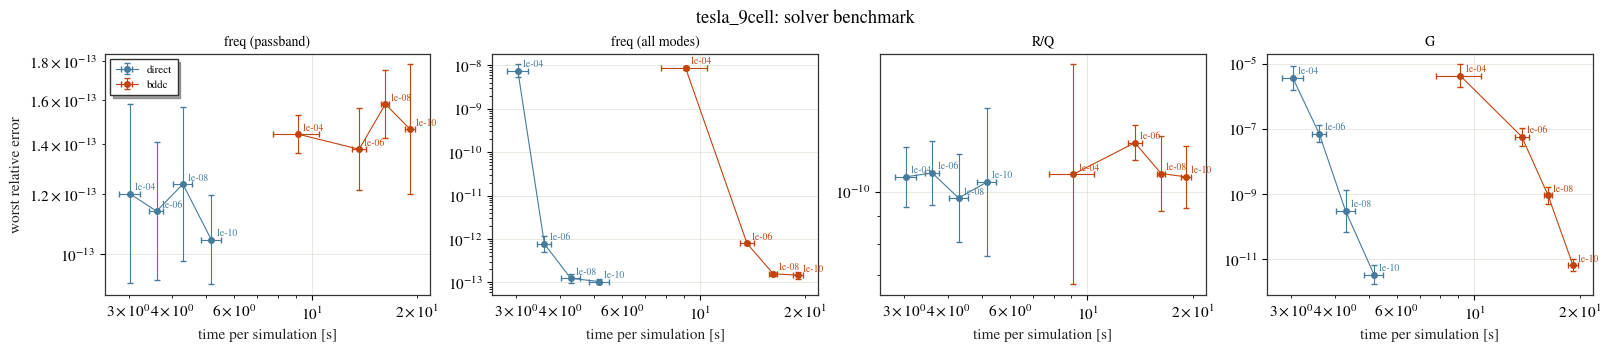

In [5]:
nine.eigenmode.plot_benchmark(errors=['freq (passband)', 'freq (all modes)', 'R/Q', 'G'])
plt.show()

The frequency error of every mode, for the direct preconditioner at each tolerance: modes 1
to 9 are the passband, 10 and 11 the next band.

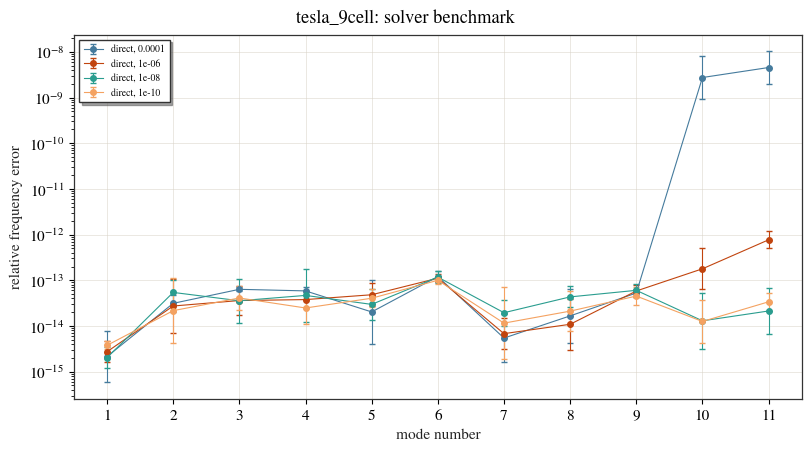

In [6]:
bench = nine.eigenmode.benchmark_df
nine.eigenmode.plot_benchmark(bench[bench['variant'] == 'direct'], kind='modes')
plt.show()

On nine cells the solve takes most of the time, and both settings show. Direct takes 3.0 s
at `1e-4` and 4.3 s at the default `1e-8`. BDDC takes three to four times as long at every
tolerance, 9.1 to 19.1 s, with five times the iterations.

Most of those iterations go to the two modes above the passband. The per-mode plot shows it:
the nine passband modes are converged to round-off at every tolerance, `1e-4` included,
while modes 10 and 11 follow the tolerance. So the passband's figures of merit are converged
to about $10^{-10}$ whatever the tolerance, and only the all-modes frequency and G, which is
scored over every reported mode, respond to it.

## 3. Converging the passband only

If only the passband will be used, `pinvit_converge_modes=9` stops the solve once those nine
have converged. The two modes above are still reported, but not converged.

In [7]:
nine.eigenmode.benchmark(variants={'every mode (default)': {},
                                   'passband only': {'pinvit_converge_modes': 9}},
                         sweep={'pinvit_tol': [1e-6, 1e-8]}, n_repeats=5,
                         eigenmode_config=CONFIG)
show(nine.eigenmode.benchmark_table())

Converging the passband alone takes 7 to 9 iterations and 2.3 s per simulation, instead of
4.0 to 5.0 s: the solve itself is about three times faster, and the passband is
converged to the tolerance asked for (R/Q to $10^{-6}$ at `1e-6`, $10^{-8}$ at `1e-8`). The
price is the two modes above. Nothing converged them, so their frequencies are up to $10^{-4}$
off and their G up to $3\times10^{-4}$. Use it when those modes will not be read.
Setting `n_modes=n_cells` does the same without reporting them at all.

## 4. Padding

The eigensolver iterates on more vectors than it reports. The extra ones, `pinvit_padding`,
are never returned, but they decide how fast the highest requested modes converge: those
converge at a rate set by the gap to the first eigenvalue outside the block of vectors. The
default is twice `n_modes`, at most 30: 6 for the single cell and 22 for nine cells.

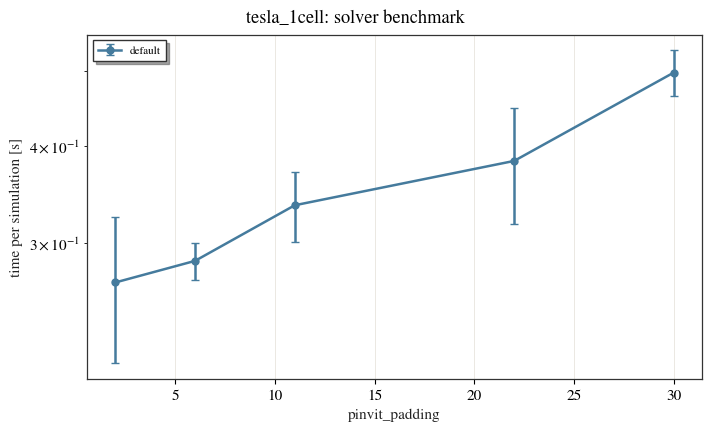

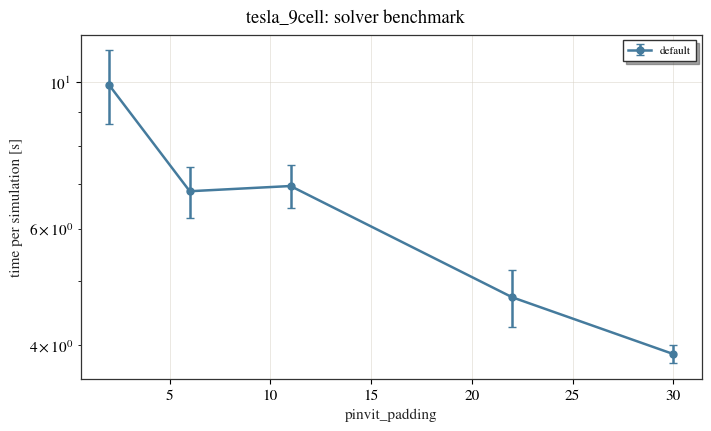

In [8]:
for cav in (cell, nine):
    cav.eigenmode.benchmark(sweep={'pinvit_padding': [2, 6, 11, 22, 30]}, n_repeats=5,
                            eigenmode_config=CONFIG)
    display(show(cav.eigenmode.benchmark_table()))
    cav.eigenmode.plot_benchmark(kind='time')
    plt.show()

On the single cell padding changes little: 0.27 to 0.28 s up to 6 extra vectors, rising to
0.5 s at 30 as every iteration carries more vectors. On nine cells it is decisive: 209
iterations and 9.9 s with 2 extra vectors, 32 and 4.7 s at the default 22, 16 and 3.9 s at
30. The two modes above the passband open the next band. With few extra vectors the first
eigenvalue outside the block sits inside that band, so the gap that sets their convergence
is small; with 22 or more the block reaches past it. The default is close to the best on a
multicell cavity and nearly free on a single cell. `pinvit_padding` sets it directly.

## 5. The sparse direct solver

Which sparse direct solvers are available depends on how NGSolve was built:
`sparsecholesky` always is, `pardiso` and `umfpack` depend on the build. A variant asking
for one this build lacks is skipped with a warning.

In [9]:
backends = {'sparsecholesky': {}, 'pardiso': {'direct_solver': 'pardiso'},
            'umfpack': {'direct_solver': 'umfpack'}}
for cav in (cell, nine):
    cav.eigenmode.benchmark(variants=backends, n_repeats=3, eigenmode_config=CONFIG)
    display(show(cav.eigenmode.benchmark_table()))

C:\Users\Soske\AppData\Local\Temp\ipykernel_39804\2965386525.py:4: UserWarning: benchmark: skipping 'umfpack', this NGSolve build has no 'umfpack' direct solver.
  cav.eigenmode.benchmark(variants=backends, n_repeats=3, eigenmode_config=CONFIG)


,time per simulation [s],std [s],solve [s],PINVIT iterations,freq (mode of interest),freq (passband),freq (all modes),R/Q,Epk/Eacc,Bpk/Eacc,G
variant,,,,,,,,,,,
sparsecholesky,0.30,0.03,0.22,14,2.0e-15,2.0e-15,1.1e-13,1.1e-09,1.2e-09,2.4e-09,4.6e-10
pardiso,4.10,0.03,4.03,14,4.7e-15,4.7e-15,7.9e-14,1.8e-09,1.8e-09,5.6e-09,1.4e-09


C:\Users\Soske\AppData\Local\Temp\ipykernel_39804\2965386525.py:4: UserWarning: benchmark: skipping 'umfpack', this NGSolve build has no 'umfpack' direct solver.
  cav.eigenmode.benchmark(variants=backends, n_repeats=3, eigenmode_config=CONFIG)


,time per simulation [s],std [s],solve [s],PINVIT iterations,freq (mode of interest),freq (passband),freq (all modes),R/Q,Epk/Eacc,Bpk/Eacc,G,ff
variant,,,,,,,,,,,,
sparsecholesky,4.50,0.43,3.36,32,2.3e-14,7.3e-14,7.3e-14,3.8e-11,2.6e-11,2.8e-11,3.4e-10,4.4e-11
pardiso,36.94,1.21,35.88,31,1.1e-15,7.7e-14,8.1e-14,2.9e-11,1.8e-11,1.5e-11,4.0e-10,3.9e-11


Both backends give the same answer, and `sparsecholesky` is the faster: 14 times on the
single cell (0.30 s against 4.1 s) and 8 times on nine cells (4.5 s against 37 s). This
build has no `umfpack`, so that variant was skipped. On a build that has it, the same cell
compares all three.

## 6. What to use

- The defaults (the direct preconditioner, `sparsecholesky`, `pinvit_tol=1e-8`, padding of
  twice `n_modes`) keep the solver's error far below any practical mesh's: figures of merit
  to about $10^{-9}$, frequencies to round-off.
- BDDC did not win anywhere here. It was 1.6 to 3.8 times slower, on both cavities and at
  every tolerance.
- The tolerance is a free knob on small problems and a real one on large ones. On nine
  cells `1e-4` takes 3.0 s against the default's 4.3 s and still leaves the passband at
  round-off, with G at $4\times10^{-6}$ and the modes above the passband at $10^{-8}$.
- On a multicell cavity the largest saving is to converge only the modes you will use:
  `pinvit_converge_modes=n_cells`, or `n_modes=n_cells`.
- Keep `direct_solver='sparsecholesky'` unless a benchmark on your own machine says
  otherwise.